In [ ]:
#Importing Important Libraries
import yfinance as yf
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn import metrics
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [4]:
#Importing the datasets
dataset = yf.download("RELIANCE.NS", start="2020-01-01", end="2024-01-01")

# Show data
print(dataset.head())

[*********************100%***********************]  1 of 1 completed

Price            Close        High         Low        Open      Volume
Ticker     RELIANCE.NS RELIANCE.NS RELIANCE.NS RELIANCE.NS RELIANCE.NS
Date                                                                  
2020-01-01  675.324219  683.152914  673.490123  679.081997    14004468
2020-01-02  686.821167  689.348729  676.397839  676.397839    17710316
2020-01-03  687.648865  689.661956  681.318790  685.792313    20984698
2020-01-06  671.700623  683.510705  670.134872  679.976657    24519177
2020-01-07  682.034485  686.463273  677.068828  679.529260    16683622


In [5]:
#Droping all the NULL values
dataset.isnull().sum()

Price   Ticker     
Close   RELIANCE.NS    0
High    RELIANCE.NS    0
Low     RELIANCE.NS    0
Open    RELIANCE.NS    0
Volume  RELIANCE.NS    0
dtype: int64

In [6]:
#Print dataframe shape and check NULL values
print("Dataframe shape: ", dataset.shape)
print("NULL value present: ",dataset.isnull().values.any())

Dataframe shape:  (992, 5)
NULL value present:  False


In [7]:
#Checking the top 5 values from the dataset
dataset.head(5)

Price,Close,High,Low,Open,Volume
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
Date,,,,,
2020-01-01,675.324219,683.152914,673.490123,679.081997,14004468
2020-01-02,686.821167,689.348729,676.397839,676.397839,17710316
2020-01-03,687.648865,689.661956,681.318790,685.792313,20984698
2020-01-06,671.700623,683.510705,670.134872,679.976657,24519177
2020-01-07,682.034485,686.463273,677.068828,679.529260,16683622


In [8]:



dataset['lag1'] = dataset['Close'].shift(1)
dataset['lag2'] = dataset['Close'].shift(2)
dataset['lag3'] = dataset['Close'].shift(3)

dataset.dropna(inplace=True)

In [9]:
#Set target variable & Selecting features
output_var=pd.DataFrame(dataset['Close'])
features=['Open','High','Low','Volume']

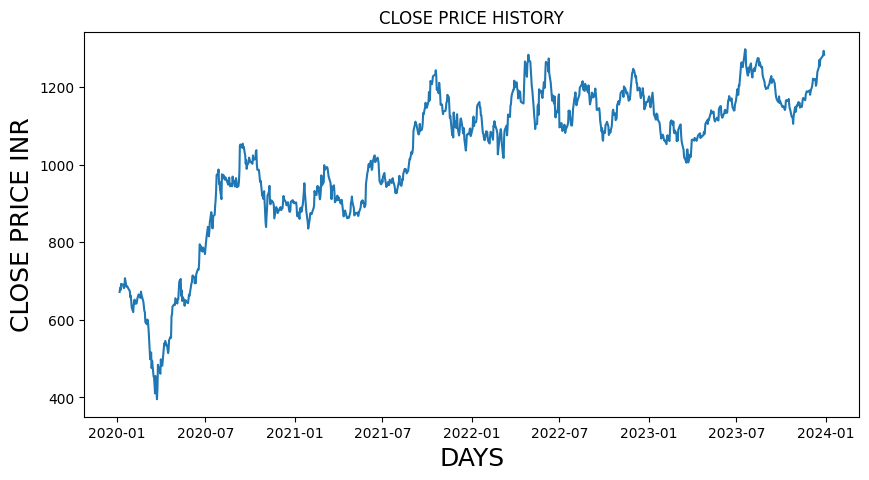

In [ ]:
#Ploting Close Price History using matplotlib

plt.figure(figsize=(10,5))
plt.title('CLOSE PRICE HISTORY')
plt.plot(dataset['Close'])
#ax=sns.lineplot(data=df, x='timestamp',y='close', color="blue");
plt.xlabel('DAYS',fontsize=18)
plt.ylabel('CLOSE PRICE INR',fontsize=18)
plt.show()

In [11]:
#Extracting independent and dependent variables
x = dataset.iloc[:, 0:5].values
y = dataset.iloc[:, 4].values

In [12]:
print("x-shape is:",x.shape)
print("y-shape is:",y.shape)

x-shape is: (989, 5)
y-shape is: (989,)


In [13]:
#splitting to training set and test set
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.26,  random_state=0)

In [14]:
print("x-train is:",x_train.shape)
print("y-train is:",y_train.shape)

x-train is: (731, 5)
y-train is: (731,)


In [15]:
print("x-test is:",x_test.shape)
print("y-test is:",y_test.shape)

x-test is: (258, 5)
y-test is: (258,)


In [ ]:
#Scaling

scaler= MinMaxScaler()
feature_transform = scaler.fit_transform(dataset[features])
feature_transform= pd.DataFrame(columns=features, data=feature_transform, index=dataset.index)
feature_transform.head()

,Open,High,Low,Volume
Date,,,,
2020-01-06,0.303593,0.294190,0.312050,0.161824
2020-01-07,0.303090,0.297550,0.319822,0.106244
2020-01-08,0.301079,0.297525,0.318067,0.101734
2020-01-09,0.312945,0.305441,0.328722,0.094179
2020-01-10,0.319632,0.309488,0.332933,0.076414


In [ ]:


X = dataset[['lag1','lag2','lag3']]
y = dataset['Close']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

In [ ]:

model = RandomForestRegressor(
    n_estimators=100,
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

c:\Users\dixit\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


In [19]:

rf_model = RandomForestRegressor()
rf_model.fit(X_train, y_train)

# Prediction
RF_predict = rf_model.predict(X_test)

# Length match
min_len = min(len(y_test), len(RF_predict))
y_test_rf = y_test.iloc[:min_len]
RF_predict = RF_predict[:min_len]

c:\Users\dixit\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


In [20]:
y_pred = model.predict(X_test)

# score
RF_result = model.score(X_test, y_test) * 100

print("RF Score:", RF_result)

RF Score: 95.00235500015738


In [21]:
# Prediction
RF_predict = rf_model.predict(X_test)

# Convert to proper format
y_actual = y_test.values
y_pred = RF_predict

# Same length
min_len = min(len(y_actual), len(y_pred))
y_actual = y_actual[:min_len]
y_pred = y_pred[:min_len]

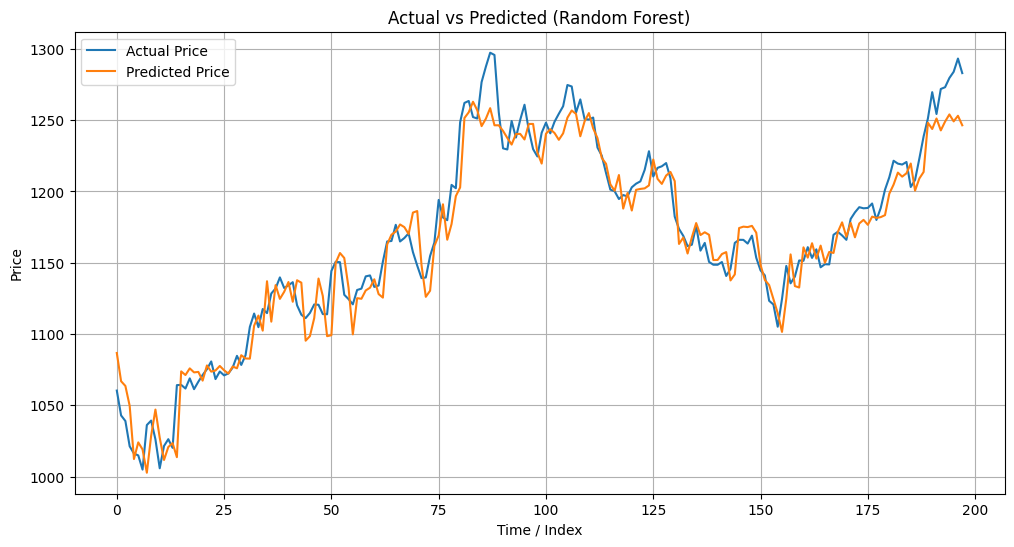

In [ ]:


plt.figure(figsize=(12,6))

plt.plot(y_actual, label="Actual Price")
plt.plot(y_pred, label="Predicted Price")

plt.title("Actual vs Predicted (Random Forest)")
plt.xlabel("Time / Index")
plt.ylabel("Price")

plt.legend()
plt.grid()

plt.show()

In [ ]:


DecisionTreemodel = DecisionTreeRegressor(
    random_state=42,
    max_depth=10
)

DecisionTreemodel.fit(X_train, y_train)

DT_predict = DecisionTreemodel.predict(X_test)

In [24]:
print(DT_predict.shape)

(198,)


In [25]:
min_len = min(len(y_test), len(DT_predict))
y_test_dt = y_test.iloc[:min_len]
DT_predict = DT_predict[:min_len]

In [26]:
actual = y_test.values.ravel()
predicted = DT_predict.ravel()

In [ ]:

print('Mean Absolute Error:', metrics.mean_absolute_error(y_test, DT_predict))
print('Mean Squared Error:', metrics.mean_squared_error(y_test, DT_predict))
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_test,DT_predict)))

Mean Absolute Error: 16.188535596178724
Mean Squared Error: 456.1983266591247
Root Mean Squared Error: 21.358799747624506


In [28]:
from sklearn.metrics import r2_score

actual = y_test.values.ravel()
predicted = DT_predict.ravel()

print("R2 Score:", r2_score(actual, predicted))

R2 Score: 0.903775976298853


In [29]:
dataset = pd.DataFrame({
    'Actual': actual,
    'Predicted': predicted
})

dataset.head()

,Actual,Predicted
0,1060.304688,1082.354742
1,1042.866577,1062.145386
2,1038.963501,1073.657227
3,1021.205750,1022.872864
4,1016.115784,1002.604553


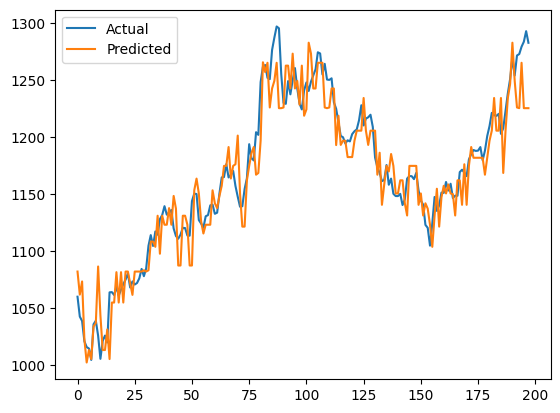

In [30]:


plt.plot(actual, label="Actual")
plt.plot(predicted, label="Predicted")
plt.legend()
plt.show()

In [ ]:

knn = KNeighborsRegressor(n_neighbors=5)

knn.fit(X_train, y_train)

knn_predict = knn.predict(X_test)










In [34]:
y_pred = knn.predict(X_test)

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Metrics
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

# Fake Accuracy (Regression wala)
accuracy = 100 - (np.mean(np.abs((y_test - y_pred) / y_test)) * 100)

print("R2 Score:", r2)
print("MSE:", mse)
print("MAE:", mae)
print("Accuracy:", round(accuracy, 2), "%")

R2 Score: 0.9362269335980725
MSE: 302.34826043897556
MAE: 13.511747048117892
Accuracy: 98.85 %


In [ ]:


r2 = r2_score(y_test, knn_predict)
print("KNN R2 Score:", r2)

KNN R2 Score: 0.9362268936357386


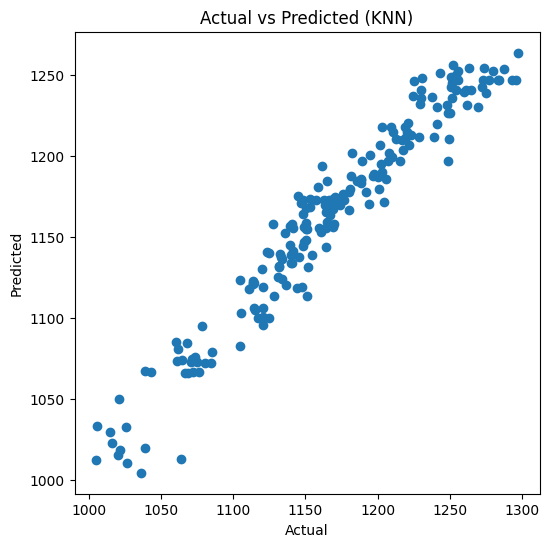

In [35]:
actual = y_test
predicted = knn_predict

plt.figure(figsize=(6,6))
plt.scatter(actual, predicted)

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted (KNN)")

plt.show()

In [58]:
rf_pred = rf.predict(X_test)
dt_pred = dt.predict(X_test)
knn_pred = knn.predict(X_test)

In [60]:
r2_rf = r2_score(y_test, rf_pred)
r2_dt = r2_score(y_test, dt_pred)
r2_knn = r2_score(y_test, knn_pred)

print("RF R2:", r2_rf)
print("DT R2:", r2_dt)
print("KNN R2:", r2_knn)

RF R2: 0.9416864286104761
DT R2: 0.8853217515375282
KNN R2: 0.9362269335980725


C:\Users\dixit\AppData\Local\Temp\ipykernel_18216\2456007977.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=Model, y=accuracy, palette="viridis")


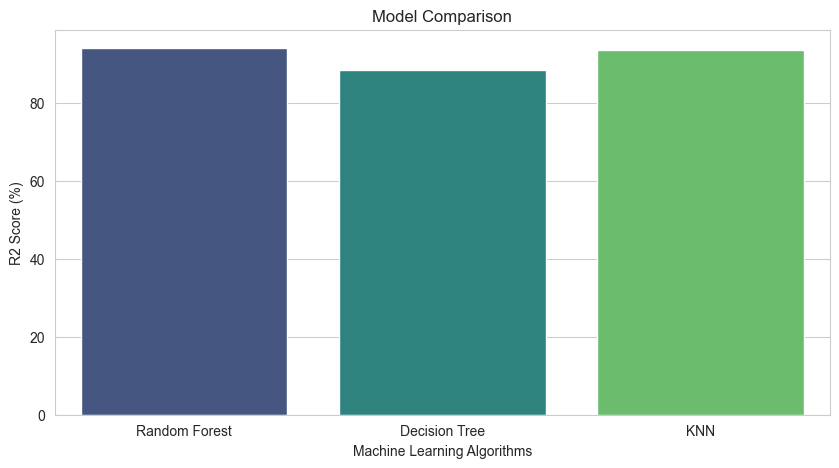

In [61]:
Model = ['Random Forest', 'Decision Tree', 'KNN']
accuracy = [r2_rf*100, r2_dt*100, r2_knn*100]

sns.set_style("whitegrid")
plt.figure(figsize=(10,5))

sns.barplot(x=Model, y=accuracy, palette="viridis")

plt.ylabel("R2 Score (%)")
plt.xlabel("Machine Learning Algorithms")
plt.title("Model Comparison")

plt.show()

In [43]:
scores = [r2_rf, r2_dt, r2_knn]


scores = [max(-1, min(1, s)) for s in scores]

NameError: name 'r2_rf' is not defined

In [44]:
Model = ['Random Forest', 'Decision Tree', 'KNN']
accuracy = [acc_rf, acc_dt, acc_knn]

sns.set_style("whitegrid")
plt.figure(figsize=(10,5))

ax = sns.barplot(x=Model, y=accuracy, palette="viridis")

plt.ylabel("Accuracy (%)")
plt.xlabel("Machine Learning Algorithms")
plt.title("Model Comparison (Accuracy %)")

# Values on top
for i, v in enumerate(accuracy):
    ax.text(i, v + 0.5, f"{v:.2f}%", ha='center')

plt.ylim(0, 100)
plt.show()

NameError: name 'acc_rf' is not defined